# ABIDE Dataset Exploration

The ABIDE (Autism Brain Imaging Data Exchange) dataset contains resting-state fMRI
and structural MRI from ~1000 subjects across 17 international sites.
Labels: **ASD** (Autism Spectrum Disorder) vs **TDC** (Typically Developing Controls).

This notebook mirrors `01_data_exploration.ipynb` but for ABIDE, validating that
the same preprocessing pipeline works before training.

In [1]:
# Standard imports — same pipeline as ADHD-200.
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader

from utils.preprocessing import (
    load_phenotypic, build_subject_file_map,
    preprocess_volume, load_nifti, get_crop_shape
)
from utils.dataset import build_datasets

# Point to the ABIDE data directory (downloaded by download_abide.py).
DATA_DIR = '../data/raw_abide'
print('Imports OK')

Imports OK


## 1. Phenotypic CSV
Check subject counts and class balance. ABIDE has ~1000 subjects vs ADHD-200's 79.

In [2]:
# Load the phenotypic CSV saved by download_abide.py.
# label=0 → ASD (Autism), label=1 → TDC (Control) — same convention as ADHD-200.
pheno = load_phenotypic(DATA_DIR)
print(f'Total subjects in CSV: {len(pheno)}')
print(f'  ASD (label=0): {(pheno["label"]==0).sum()}')
print(f'  TDC (label=1): {(pheno["label"]==1).sum()}')
print(f'Columns: {list(pheno.columns)}')
pheno.head()

Total subjects in CSV: 50
  ASD (label=0): 27
  TDC (label=1): 23
Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'SUB_ID', 'X', 'subject', 'SITE_ID', 'subject_id', 'dx', 'DSM_IV_TR', 'AGE_AT_SCAN', 'SEX', 'HANDEDNESS_CATEGORY', 'HANDEDNESS_SCORES', 'FIQ', 'VIQ', 'PIQ', 'FIQ_TEST_TYPE', 'VIQ_TEST_TYPE', 'PIQ_TEST_TYPE', 'ADI_R_SOCIAL_TOTAL_A', 'ADI_R_VERBAL_TOTAL_BV', 'ADI_RRB_TOTAL_C', 'ADI_R_ONSET_TOTAL_D', 'ADI_R_RSRCH_RELIABLE', 'ADOS_MODULE', 'ADOS_TOTAL', 'ADOS_COMM', 'ADOS_SOCIAL', 'ADOS_STEREO_BEHAV', 'ADOS_RSRCH_RELIABLE', 'ADOS_GOTHAM_SOCAFFECT', 'ADOS_GOTHAM_RRB', 'ADOS_GOTHAM_TOTAL', 'ADOS_GOTHAM_SEVERITY', 'SRS_VERSION', 'SRS_RAW_TOTAL', 'SRS_AWARENESS', 'SRS_COGNITION', 'SRS_COMMUNICATION', 'SRS_MOTIVATION', 'SRS_MANNERISMS', 'SCQ_TOTAL', 'AQ_TOTAL', 'COMORBIDITY', 'CURRENT_MED_STATUS', 'MEDICATION_NAME', 'OFF_STIMULANTS_AT_SCAN', 'VINELAND_RECEPTIVE_V_SCALED', 'VINELAND_EXPRESSIVE_V_SCALED', 'VINELAND_WRITTEN_V_SCALED', 'VINELAND_COMMUNICATION_STANDARD', 'VINELAND_PERSONAL_V_SCA

,Unnamed: 0.1,Unnamed: 0,SUB_ID,X,subject,SITE_ID,subject_id,dx,DSM_IV_TR,AGE_AT_SCAN,...,qc_anat_rater_2,qc_anat_notes_rater_2,qc_func_rater_2,qc_func_notes_rater_2,qc_anat_rater_3,qc_anat_notes_rater_3,qc_func_rater_3,qc_func_notes_rater_3,SUB_IN_SMP,label
0,0,1,50002,1,50002,PITT,no_filename,1,1,16.77,...,OK,NaN,fail,ic-parietal-cerebellum,OK,NaN,fail,ERROR #24,1,0
1,1,2,50003,2,50003,PITT,Pitt_0050003,1,1,24.45,...,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1,0
2,2,3,50004,3,50004,PITT,Pitt_0050004,1,1,19.09,...,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1,0
3,3,4,50005,4,50005,PITT,Pitt_0050005,1,1,13.73,...,OK,NaN,maybe,ic-parietal-cerebellum,OK,NaN,OK,NaN,0,0
4,4,5,50006,5,50006,PITT,Pitt_0050006,1,1,13.37,...,OK,NaN,maybe,ic-parietal slight,OK,NaN,OK,NaN,1,0


## 2. Subject File Map
Check how many subjects have all 3 derivatives downloaded successfully.

In [3]:
file_map = build_subject_file_map(DATA_DIR)
print(f'Subjects with at least one derivative: {len(file_map)}')

complete = [sid for sid, d in file_map.items() if 'falff' in d and 'reho' in d]
falff_only = [sid for sid, d in file_map.items() if 'falff' in d]
gm_only    = [sid for sid, d in file_map.items() if 'gm' in d]

print(f'Subjects with fALFF + ReHo: {len(complete)}')
print(f'Subjects with fALFF: {len(falff_only)}')
print(f'Subjects with GM:    {len(gm_only)}')

if complete:
    sid = complete[0]
    print(f'\nExample subject {sid}:')
    for k, v in file_map[sid].items():
        print(f'  {k}: {v}')

Subjects with at least one derivative: 49
Subjects with fALFF + ReHo: 49
Subjects with fALFF: 49
Subjects with GM:    0

Example subject Pitt_0050003:
  falff: /Users/luis/Desktop/CSCI1470/csci1470-final-project/data/raw_abide/Pitt_0050003/falff.nii.gz
  reho: /Users/luis/Desktop/CSCI1470/csci1470-final-project/data/raw_abide/Pitt_0050003/reho.nii.gz


## 3. Raw Volume Shapes
ABIDE volumes may differ in shape from ADHD-200. Luis added zero-padding in
`preprocessing.py` to handle volumes smaller than the crop target.

In [4]:
# Check raw shapes for the first complete subject.
# Target crop shapes: fMRI → (47,60,46), sMRI → (90,117,100).
# Volumes smaller than the target will be zero-padded before cropping.
if complete:
    sid = complete[0]
    for deriv, path in file_map[sid].items():
        vol = load_nifti(path)
        target = get_crop_shape(deriv)
        fits = all(v >= t for v, t in zip(vol.shape, target))
        print(f'{deriv:6s}: raw={vol.shape}  target={target}  '
              f'fits={fits}  min={vol.min():.3f}  max={vol.max():.3f}')

# Check across all subjects — count how many need padding.
print('\nChecking all subjects for padding requirement...')
needs_padding = []
for s in complete:
    for deriv, path in file_map[s].items():
        vol = load_nifti(path)
        target = get_crop_shape(deriv)
        if not all(v >= t for v, t in zip(vol.shape, target)):
            needs_padding.append((s, deriv, vol.shape))

print(f'  Subjects needing padding: {len(needs_padding)} / {len(complete)*3} volumes')
if needs_padding:
    for x in needs_padding[:5]:
        print(f'    {x}')

falff : raw=(61, 73, 61)  target=(47, 60, 46)  fits=True  min=0.000  max=0.738
reho  : raw=(61, 73, 61)  target=(47, 60, 46)  fits=True  min=0.000  max=0.425

Checking all subjects for padding requirement...
  Subjects needing padding: 0 / 147 volumes


## 4. Normalization Check
Verify z-score normalization brings all volumes to zero mean and unit std.

In [5]:
# Before normalization: raw intensity values vary widely across subjects and sites.
# After normalization: mean ≈ 0, std ≈ 1 for every volume.
if complete:
    sid = complete[0]
    for deriv, path in file_map[sid].items():
        raw = load_nifti(path)
        t   = preprocess_volume(path, deriv).squeeze().numpy()
        print(f'{deriv:6s}  raw: mean={raw.mean():.4f} std={raw.std():.4f} '
              f'  →  normed: mean={t.mean():.4f} std={t.std():.4f}')

falff   raw: mean=0.1132 std=0.2167   →  normed: mean=-0.0000 std=1.0000
reho    raw: mean=0.0251 std=0.0528   →  normed: mean=-0.0000 std=1.0000


## 5. Shape Check Across All Subjects
Every preprocessed volume must be exactly the crop target shape.

In [6]:
errors = []
for sid in complete:
    for deriv, path in file_map[sid].items():
        try:
            t = preprocess_volume(path, deriv)
            expected = get_crop_shape(deriv)
            if tuple(t.shape[1:]) != expected:
                errors.append((sid, deriv, f'shape mismatch: {tuple(t.shape)}'))
        except Exception as e:
            errors.append((sid, deriv, str(e)))

n_vols = sum(len(file_map[s]) for s in complete)
if errors:
    print(f'ERRORS ({len(errors)}):')
    for e in errors: print(' ', e)
else:
    print(f'All {n_vols} volumes passed shape check.')

All 98 volumes passed shape check.


## 6. Class Distribution
Check ASD/TDC balance across the downloaded subjects.

Subjects in fALFF dataset: 49
  ASD (label=0): 26  (53.1%)
  TDC (label=1): 23  (46.9%)


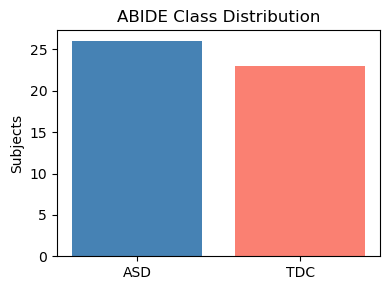

In [7]:
# A heavily imbalanced dataset can bias the model toward the majority class.
# ABIDE is roughly 50/50 but varies by site.
ds_falff = build_datasets(DATA_DIR, derivative='falff')
labels_all = [ds_falff[i][1] for i in range(len(ds_falff))]
counts = Counter(labels_all)

print(f'Subjects in fALFF dataset: {len(ds_falff)}')
print(f'  ASD (label=0): {counts[0]}  ({100*counts[0]/len(ds_falff):.1f}%)')
print(f'  TDC (label=1): {counts[1]}  ({100*counts[1]/len(ds_falff):.1f}%)')

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['ASD', 'TDC'], [counts[0], counts[1]], color=['steelblue', 'salmon'])
ax.set_ylabel('Subjects')
ax.set_title('ABIDE Class Distribution')
plt.tight_layout()
plt.show()

## True Class Distribution
Got the numbers straight from Oscar

In [ ]:
import matplotlib.pyplot as plt

asd_count = 539 
tdc_count = 573 
total_subjects = asd_count + tdc_count

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['ASD', 'TDC'], [asd_count, tdc_count], color=['steelblue', 'salmon'])
ax.set_ylabel('Subjects')
ax.set_title(f'ABIDE Class Distribution (n={total_subjects})') 

plt.tight_layout()
plt.show()

## 7. Brain Slice Visualisation
Compare axial mid-slices of fALFF, ReHo, and GM for one ABIDE subject.

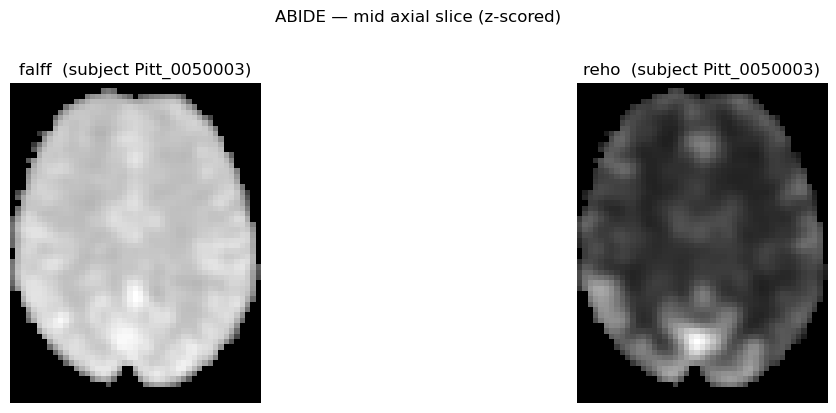

In [8]:
# Visual sanity check — slices should look like brain maps, not noise or all zeros.
# fALFF/ReHo show functional activation patterns; GM shows grey matter density.
if complete:
    sid = complete[0]
    fig, axes = plt.subplots(1, len(file_map[sid]), figsize=(14, 4))
    for ax, (deriv, path) in zip(axes, file_map[sid].items()):
        t = preprocess_volume(path, deriv).squeeze().numpy()
        mid = t.shape[2] // 2
        ax.imshow(t[:, :, mid].T, cmap='gray', origin='lower')
        ax.set_title(f'{deriv}  (subject {sid})')
        ax.axis('off')
    plt.suptitle('ABIDE — mid axial slice (z-scored)', y=1.02)
    plt.tight_layout()
    plt.show()

## 8. Dataset Objects
Build PyTorch datasets for all three derivatives and verify shapes.

In [9]:
# Build datasets for all three modalities.
# These are the objects that will be fed into the DataLoader during training.
ds_falff = build_datasets(DATA_DIR, derivative='falff')
ds_reho  = build_datasets(DATA_DIR, derivative='reho')
ds_gm    = build_datasets(DATA_DIR, derivative='gm')
ds_multi = build_datasets(DATA_DIR, multi_modal=True)

print(f'fALFF dataset : {len(ds_falff)} subjects')
print(f'ReHo  dataset : {len(ds_reho)} subjects')
print(f'GM    dataset : {len(ds_gm)} subjects')
print(f'Multi dataset : {len(ds_multi)} subjects')

tensor, label = ds_falff[0]
print(f'\nfALFF sample 0 — shape: {tuple(tensor.shape)}, label: {label} ({"ASD" if label==0 else "TDC"})')

fmri, smri, label = ds_multi[0]
print(f'Multi  sample 0 — fMRI: {tuple(fmri.shape)}, sMRI: {tuple(smri.shape)}, label: {label}')

fALFF dataset : 49 subjects
ReHo  dataset : 49 subjects
GM    dataset : 0 subjects
Multi dataset : 0 subjects

fALFF sample 0 — shape: (1, 47, 60, 46), label: 0 (ASD)


IndexError: list index out of range

## 9. Compare ABIDE vs ADHD-200
Side-by-side stats to understand how the two datasets differ.

In [10]:
# ABIDE is larger and from more sites, which may help or hurt generalization.
# Both use CPAC preprocessing so the derivatives should be comparable.
import pandas as pd

adhd_pheno = load_phenotypic('../data/raw')
abide_pheno = load_phenotypic('../data/raw_abide')

rows = [
    {'Dataset': 'ADHD-200', 'Total': len(adhd_pheno),
     'Disorder': (adhd_pheno['label']==0).sum(),
     'Control':  (adhd_pheno['label']==1).sum(),
     'Task': 'ADHD classification'},
    {'Dataset': 'ABIDE',    'Total': len(abide_pheno),
     'Disorder': (abide_pheno['label']==0).sum(),
     'Control':  (abide_pheno['label']==1).sum(),
     'Task': 'Autism classification'},
]

df = pd.DataFrame(rows)
print(df.to_string(index=False))

FileNotFoundError: phenotypic.csv not found in ../data/raw. Run scripts/run_downloads.sh first.